<a href="https://colab.research.google.com/github/beyonddbold-ux/ML-Models/blob/main/predictive_an_28_july.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import  matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
# laod dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df=pd.read_csv(url, parse_dates=['Month'], index_col =['Month'])

In [4]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


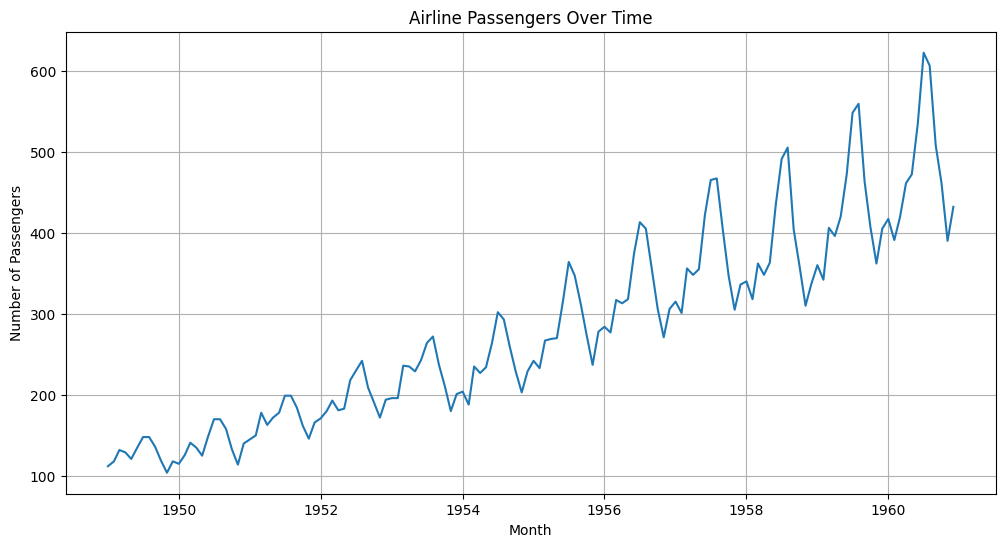

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Passengers'])
plt.title('Airline Passengers Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()

Increasing trend and seasonality is not constant by number it is increasing by percentage terms So we will go with Multiplicative model

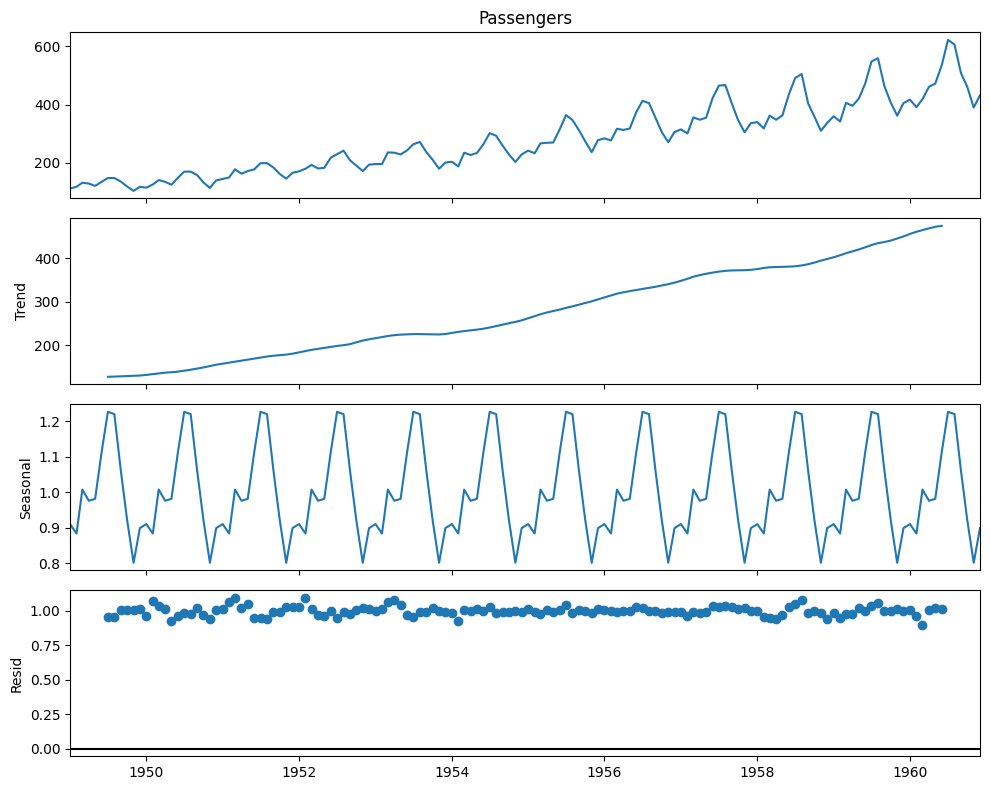

In [6]:
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative')
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

In [7]:
from statsmodels.tsa.seasonal import STL

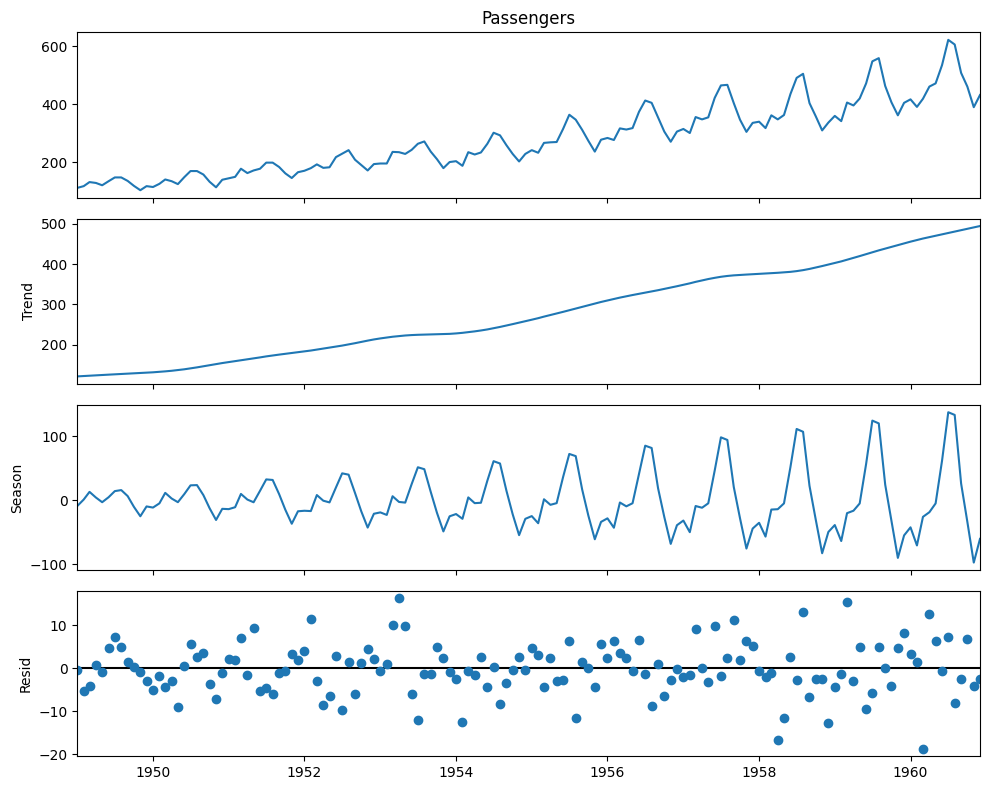

In [8]:
stl = STL(df['Passengers'], seasonal=13)
result = stl.fit()
fig = result.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

In [10]:
# Remove the trend component from the 'Passengers' data
df['Detrended_Passengers'] = df['Passengers'] / result.trend

# Display the first few rows of the DataFrame with the new detrended column
display(df[['Passengers', 'Detrended_Passengers']].head())

,Passengers,Detrended_Passengers
Month,,
1949-01-01,112,0.922089
1949-02-01,118,0.964111
1949-03-01,132,1.070697
1949-04-01,129,1.039149
1949-05-01,121,0.968254


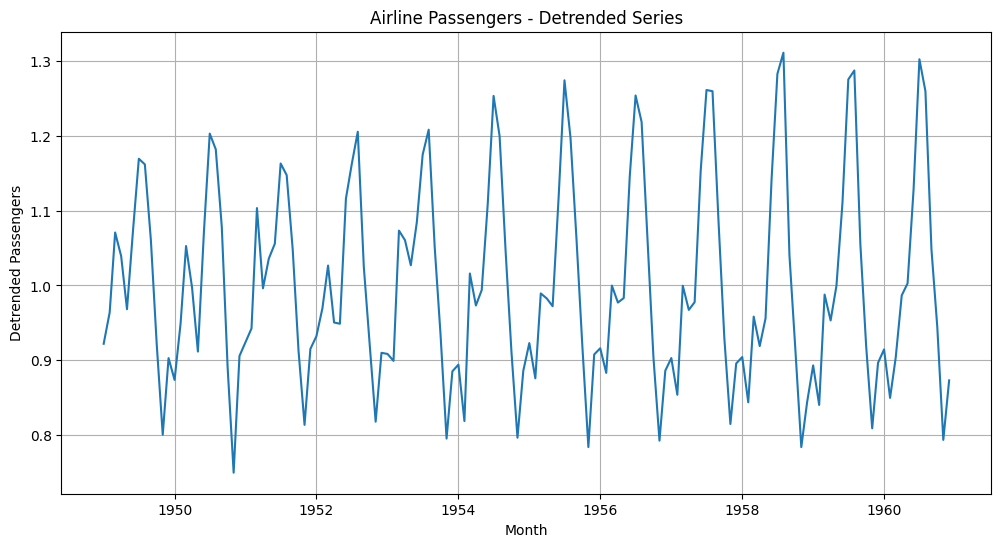

In [11]:
# Plot the detrended series
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Detrended_Passengers'])
plt.title('Airline Passengers - Detrended Series')
plt.xlabel('Month')
plt.ylabel('Detrended Passengers')
plt.grid(True)
plt.show()

we are removing the trend component from the data

In [12]:
# Remove the seasonal component from the detrended data
df['Deseasonalized_Passengers'] = df['Detrended_Passengers'] / result.seasonal

# Display the first few rows of the DataFrame with the new deseasonalized column
display(df[['Passengers', 'Detrended_Passengers', 'Deseasonalized_Passengers']].head())

,Passengers,Detrended_Passengers,Deseasonalized_Passengers
Month,,,
1949-01-01,112,0.922089,-0.100696
1949-02-01,118,0.964111,1.002865
1949-03-01,132,1.070697,0.082874
1949-04-01,129,1.039149,0.257053
1949-05-01,121,0.968254,-0.302897


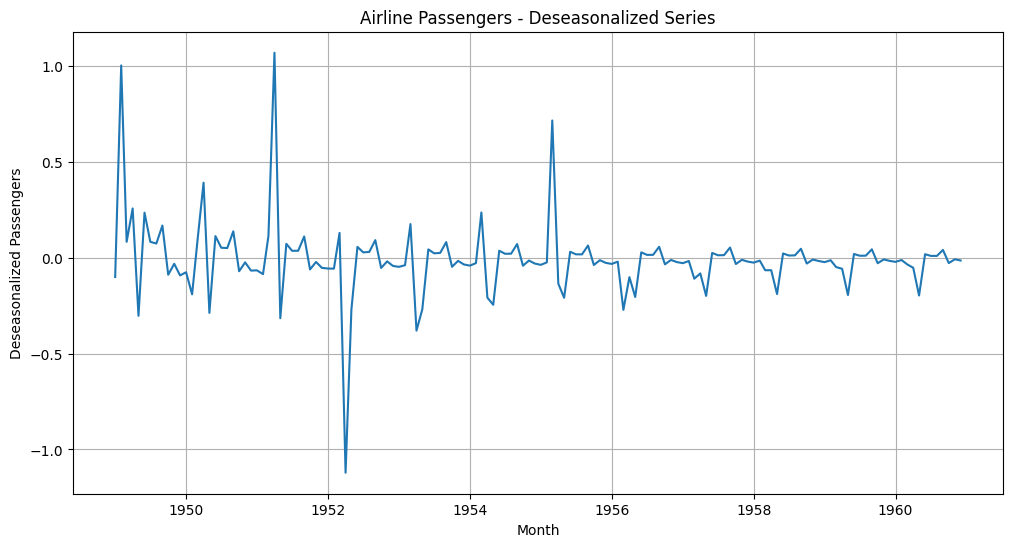

In [13]:
# Plot the deseasonalized series
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Deseasonalized_Passengers'])
plt.title('Airline Passengers - Deseasonalized Series')
plt.xlabel('Month')
plt.ylabel('Deseasonalized Passengers')
plt.grid(True)
plt.show()

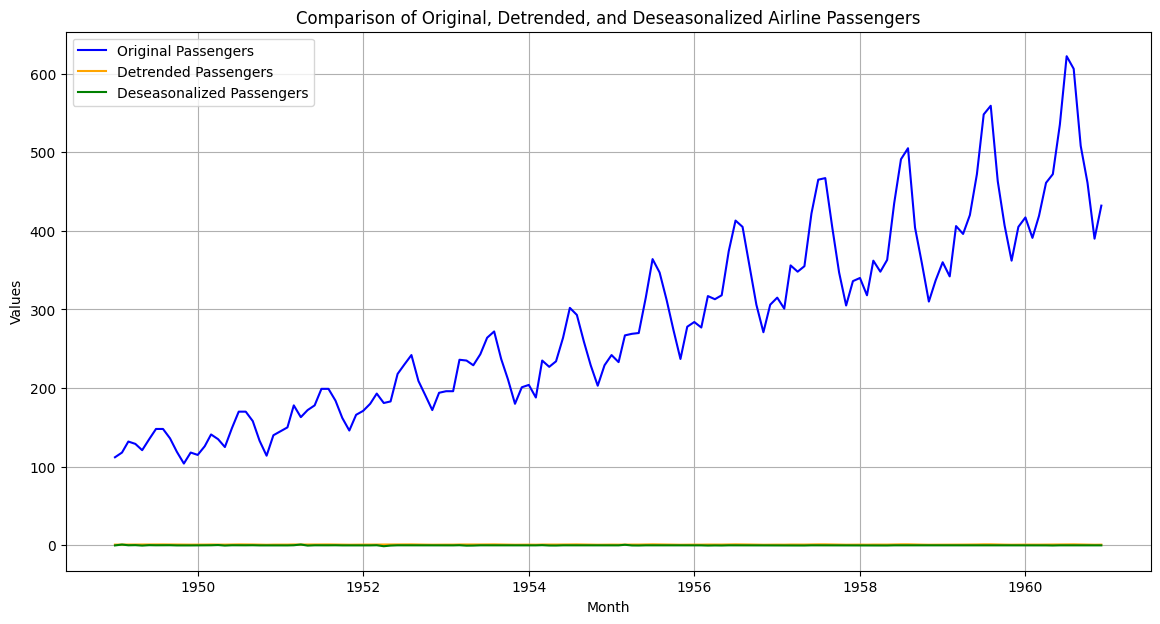

In [15]:
plt.figure(figsize=(14, 7))

plt.plot(df.index, df['Passengers'], label='Original Passengers', color='blue')
plt.plot(df.index, df['Detrended_Passengers'], label='Detrended Passengers', color='orange')
plt.plot(df.index, df['Deseasonalized_Passengers'], label='Deseasonalized Passengers', color='green')

plt.title('Comparison of Original, Detrended, and Deseasonalized Airline Passengers')
plt.xlabel('Month')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()

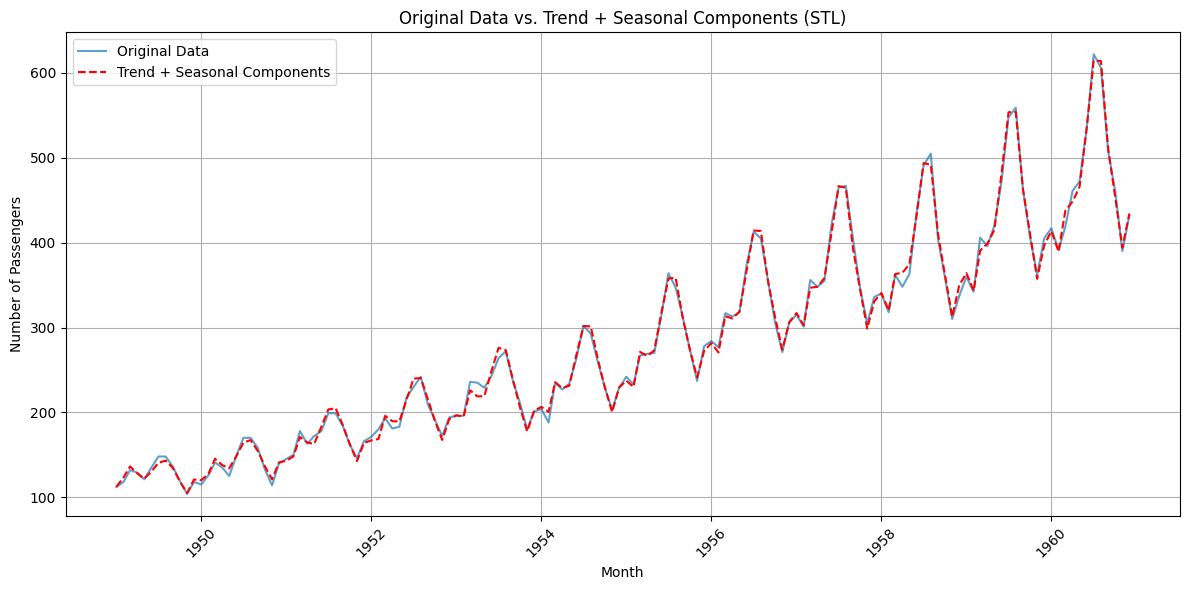

In [17]:
trend_seasonal_combined = result.trend + result.seasonal

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Passengers'], label='Original Data', alpha=0.7)
plt.plot(df.index, trend_seasonal_combined, label='Trend + Seasonal Components', color='red', linestyle='--')
plt.title('Original Data vs. Trend + Seasonal Components (STL)')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

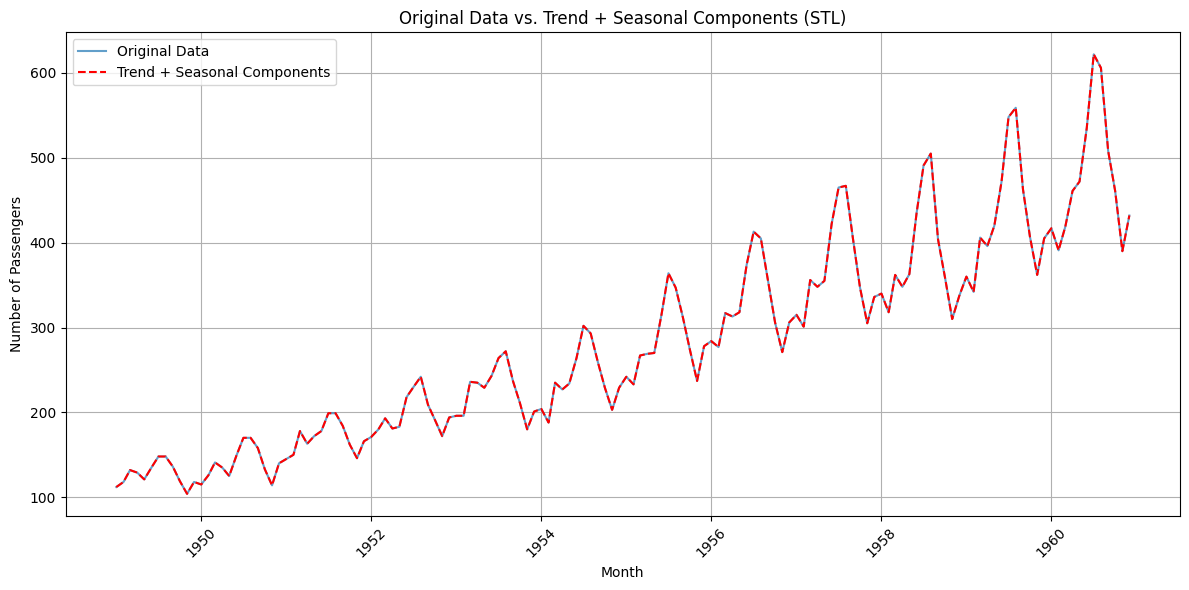

In [18]:
trend_seasonal_combined = result.trend + result.seasonal + result.resid

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Passengers'], label='Original Data', alpha=0.7)
plt.plot(df.index, trend_seasonal_combined, label='Trend + Seasonal Components', color='red', linestyle='--')
plt.title('Original Data vs. Trend + Seasonal Components (STL)')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()